# Modeling

---


## Metode

| Aspek | Keputusan |
|-------|-----------|
| Metrik utama | **F1 Macro** dimana lebih adil untuk multiclass (Low/Medium/High) |
| Evaluasi akhir | Held out test set yang sama untuk semua model |
| Deteksi overfit | Learning curve dengan train vs validation F1 across training sizes |

Kami menguji lima model dasar (Logistic Regression, SVM, Random Forest, Naive Bayes, KNN) ditambah satu soft-voting ensemble dengan bobot sama rata.

## 1. Import Library dan Konfigurasi

Library yang digunakan:
- **pandas/numpy** untuk manipulasi data.
- **matplotlib/seaborn** untuk visualisasi.
- **scikit-learn** untuk split data, pipeline preprocessing, training model, evaluasi, dan cross-validation.
- **joblib/json** untuk menyimpan model dan metadata deployment.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=plt.cm.Set2.colors)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
LABELS = ["Low", "Medium", "High"]
LABEL_TO_INT = {label: idx for idx, label in enumerate(LABELS)}
INT_TO_LABEL = {idx: label for label, idx in LABEL_TO_INT.items()}

FEATURE_COLS = [
    "age", "experience_years", "daily_work_hours", "sleep_hours",
    "caffeine_intake", "bugs_per_day", "commits_per_day",
    "meetings_per_day", "screen_time", "exercise_hours",
]

TARGET_COL = "burnout_level"
DROPPED_COLS = ["stress_level"]
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

## 2. Load Raw Dataset

Model dilatih dari raw dataset (`dataset.csv`) agar preprocessing dilakukan hanya berdasarkan data training di dalam pipeline. Ini lebih aman dibanding melakukan imputasi sebelum train-test split karena bisa menyebabkan informasi dari test set ikut masuk ke proses training.

In [2]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
print(f'Fitur: {[c for c in df.columns if c != "burnout_encoded"]}')
display(df.head())
display(df.isna().sum().to_frame("missing_count"))
display(df[TARGET_COL].value_counts(dropna=False).to_frame("count"))

Shape: (7000, 12)
Fitur: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'burnout_level']


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


,missing_count
age,140
experience_years,140
daily_work_hours,140
sleep_hours,140
caffeine_intake,140
bugs_per_day,140
commits_per_day,140
meetings_per_day,140
screen_time,140
exercise_hours,140


,count
burnout_level,
Medium,3485
High,1782
Low,1593
NaN,140


## 3. Target Handling dan Feature Selection

Row dengan target kosong dihapus karena target adalah sebuah ground truth yang sebaiknya tidak dimanipulasi. Sedangkan, fitur numerik yang kosong tidak dihapus, akan diisi oleh `SimpleImputer` dengan teknik median di dalam pipeline.

`stress_level` tidak digunakan sebagai fitur karena terlalu mirip secara konsep dengan label burnout. Menggunakan fitur ini bisa menyebabkan target leakage.

In [3]:
df_model = df.dropna(subset=[TARGET_COL]).copy()

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL].map(LABEL_TO_INT)

print("Original rows:", len(df))
print("Rows used after dropping missing targets:", len(df_model))
print("Dropped missing target rows:", df[TARGET_COL].isna().sum())
print("Features used:", FEATURE_COLS)
print("Dropped columns:", DROPPED_COLS)

display(X.head())

Original rows: 7000
Rows used after dropping missing targets: 6860
Dropped missing target rows: 140
Features used: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours']
Dropped columns: ['stress_level']


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36


## 4. Stratified Train-Test Split

Data dibagi menjadi 80% training dan 20% testing. Parameter `stratify=y` digunakan agar proporsi kelas Low, Medium, dan High tetap seimbang pada train set dan test set.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class distribution:")
print(y_train.value_counts(normalize=True).sort_index().rename(index=INT_TO_LABEL))
print("Test class distribution:")
print(y_test.value_counts(normalize=True).sort_index().rename(index=INT_TO_LABEL))

Train shape: (5488, 10)
Test shape: (1372, 10)
Train class distribution:
burnout_level
Low       0.232143
Medium    0.508017
High      0.259840
Name: proportion, dtype: float64
Test class distribution:
burnout_level
Low       0.232507
Medium    0.508017
High      0.259475
Name: proportion, dtype: float64


### Visualisasi Distribusi Kelas Setelah Split

Memastikan pembagian train-test tidak merusak proporsi kelas target. Ini penting karena evaluasi bisa bias jika salah satu kelas terlalu banyak/hilang pada test set.

,train,test
burnout_level,,
Low,0.232143,0.232507
Medium,0.508017,0.508017
High,0.259840,0.259475


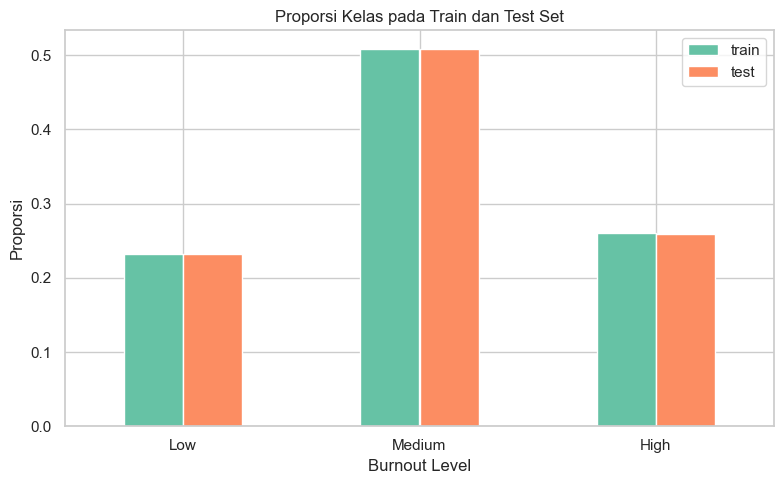

In [5]:
split_dist = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
})
split_dist.index = split_dist.index.map(INT_TO_LABEL)

display(split_dist)

split_dist.plot(kind="bar", figsize=(8, 5))
plt.title("Proporsi Kelas pada Train dan Test Set")
plt.xlabel("Burnout Level")
plt.ylabel("Proporsi")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Classical ML Pipelines

Setiap model kami buat dalam bentuk pipeline agar preprocessing masuk ke proses cross-validation dengan tepat.

Model yang digunakan:
- **Logistic Regression**: baseline linear yang mudah diinterpretasikan.
- **SVM**: model margin-based dengan kernel RBF untuk pola non-linear.
- **Random Forest**: ensemble decision tree yang relatif kuat dan bisa memberi feature importance.
- **Naive Bayes**: baseline probabilistik sederhana.
- **KNN**: model berbasis jarak yang sensitif terhadap scaling.

Scaling diberikan pada model yang sensitif terhadap skala fitur, seperti Logistic Regression, SVM, dan KNN.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold

RANDOM_STATE = 42

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1,
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            solver="lbfgs"
        )),
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=1,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        )),
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_split=15,
            min_samples_leaf=6,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1
        )),
    ]),

    "Naive Bayes": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GaussianNB(
            var_smoothing=1e-9
        )),
    ]),

    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=11,
            weights="uniform",
            metric="manhattan"
        )),
    ]),
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

## 6. Helper Functions untuk Evaluasi dan Visualisasi

Berfungsi agar proses evaluasi setiap model konsisten. Metrik utama yang digunakan adalah **F1 Macro** karena setiap kelas burnout perlu dianggap sama pentingnya, bukan hanya kelas dengan jumlah mayoritas.

In [7]:
results = {}


def evaluate_model(name, estimator, X_train, X_test, y_train, y_test):
    print(f"Training {name}...")
    cv_scores = cross_val_score(estimator, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)

    fitted_estimator = clone(estimator)
    fitted_estimator.fit(X_train, y_train)
    y_pred = fitted_estimator.predict(X_test)

    results[name] = {
        "estimator": fitted_estimator,
        "cv_f1_macro": float(cv_scores.mean()),
        "cv_f1_macro_std": float(cv_scores.std()),
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_f1_macro": float(f1_score(y_test, y_pred, average="macro")),
        "classification_report": classification_report(y_test, y_pred, target_names=LABELS, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    }

    print(f"CV F1 Macro : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test F1 Macro: {results[name]['test_f1_macro']:.4f}")
    print(f"Test Accuracy : {results[name]['test_accuracy']:.4f}")
    print(classification_report(y_test, y_pred, target_names=LABELS))

    return fitted_estimator


def plot_confusion_matrix_for_model(name):
    cm = np.array(results[name]["confusion_matrix"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def plot_learning_curve_for_model(name, estimator):
    # Learning curve memakai subset agar notebook tetap ringan saat dijalankan di laptop
    # Evaluasi utama tetap memakai seluruh X_train pada cell training model
    if len(X_train) > 1500:
        X_lc, _, y_lc, _ = train_test_split(
            X_train,
            y_train,
            train_size=1500,
            random_state=RANDOM_STATE,
            stratify=y_train
        )
    else:
        X_lc, y_lc = X_train, y_train

    lc_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_sizes, train_scores, val_scores = learning_curve(
        clone(estimator),
        X_lc,
        y_lc,
        cv=lc_cv,
        scoring="f1_macro",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    gap = train_mean[-1] - val_mean[-1]

    if gap > 0.10:
        diagnosis = f"Overfit gap = {gap:.3f} (> 0.10)"
    elif val_mean[-1] < 0.50:
        diagnosis = f"Underfit val F1 = {val_mean[-1]:.3f} (< 0.50)"
    else:
        diagnosis = f"Good fit gap = {gap:.3f}"

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(
        train_sizes,
        train_mean,
        "o-",
        color="#2ecc71",
        linewidth=2,
        label="Train F1 Macro"
    )

    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15,
        color="#2ecc71"
    )

    ax.plot(
        train_sizes,
        val_mean,
        "o-",
        color="#e74c3c",
        linewidth=2,
        label="Validation F1 Macro"
    )

    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15,
        color="#e74c3c"
    )

    ax.set_title(
        f"Learning Curve - {name}\n{diagnosis}",
        fontweight="bold",
        fontsize=11
    )

    ax.set_xlabel("Training Size")
    ax.set_ylabel("F1 Macro")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

## 7. Train dan Evaluate Semua Model

Semua model dilatih dan dievaluasi dengan prosedur yang sama. Tujuannya agar perbandingan antar model adil dan mudah diinterpretasikan.

Training Logistic Regression...
CV F1 Macro : 0.7699 ± 0.0099
Test F1 Macro: 0.7781
Test Accuracy : 0.7748
              precision    recall  f1-score   support

         Low       0.71      0.84      0.77       319
      Medium       0.83      0.70      0.76       697
        High       0.76      0.85      0.80       356

    accuracy                           0.77      1372
   macro avg       0.77      0.80      0.78      1372
weighted avg       0.78      0.77      0.77      1372



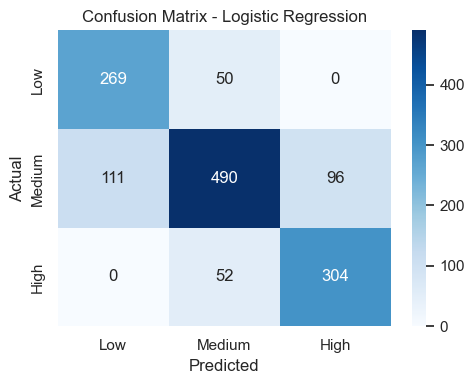

Training SVM...
CV F1 Macro : 0.7610 ± 0.0123
Test F1 Macro: 0.7625
Test Accuracy : 0.7587
              precision    recall  f1-score   support

         Low       0.69      0.84      0.76       319
      Medium       0.81      0.68      0.74       697
        High       0.75      0.83      0.79       356

    accuracy                           0.76      1372
   macro avg       0.75      0.79      0.76      1372
weighted avg       0.77      0.76      0.76      1372



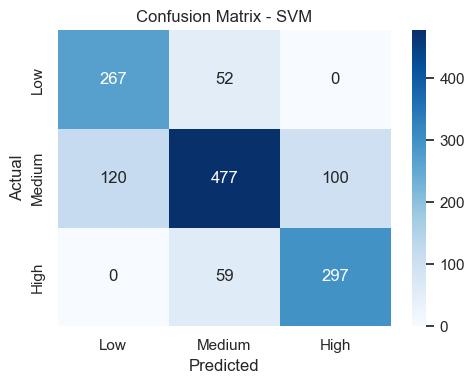

Training Random Forest...
CV F1 Macro : 0.7268 ± 0.0142
Test F1 Macro: 0.7455
Test Accuracy : 0.7405
              precision    recall  f1-score   support

         Low       0.67      0.83      0.75       319
      Medium       0.80      0.65      0.72       697
        High       0.72      0.84      0.77       356

    accuracy                           0.74      1372
   macro avg       0.73      0.77      0.75      1372
weighted avg       0.75      0.74      0.74      1372



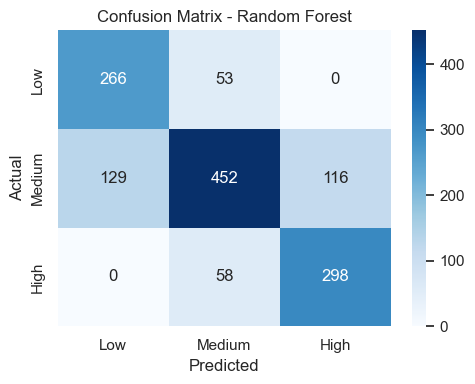

Training Naive Bayes...
CV F1 Macro : 0.7291 ± 0.0118
Test F1 Macro: 0.7649
Test Accuracy : 0.7697
              precision    recall  f1-score   support

         Low       0.77      0.72      0.74       319
      Medium       0.76      0.80      0.78       697
        High       0.80      0.75      0.77       356

    accuracy                           0.77      1372
   macro avg       0.77      0.76      0.76      1372
weighted avg       0.77      0.77      0.77      1372



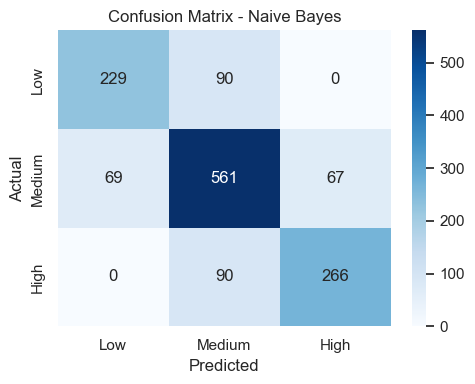

Training KNN...
CV F1 Macro : 0.7206 ± 0.0171
Test F1 Macro: 0.7453
Test Accuracy : 0.7580
              precision    recall  f1-score   support

         Low       0.78      0.64      0.70       319
      Medium       0.72      0.85      0.78       697
        High       0.84      0.68      0.75       356

    accuracy                           0.76      1372
   macro avg       0.78      0.72      0.75      1372
weighted avg       0.77      0.76      0.76      1372



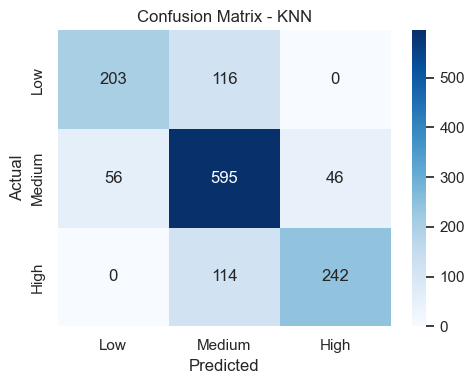

In [8]:
for name, pipe in models.items():
    evaluate_model(name, pipe, X_train, X_test, y_train, y_test)
    plot_confusion_matrix_for_model(name)

## 8. Learning Curve

Learning curve digunakan untuk melihat apakah model cenderung overfitting atau underfitting:
- Jika skor train tinggi tetapi validasi rendah, ada indikasi overfitting.
- Jika train dan validasi sama-sama rendah, ada indikasi underfitting.
- Jika validasi naik saat data bertambah, model masih mungkin terbantu oleh data tambahan.

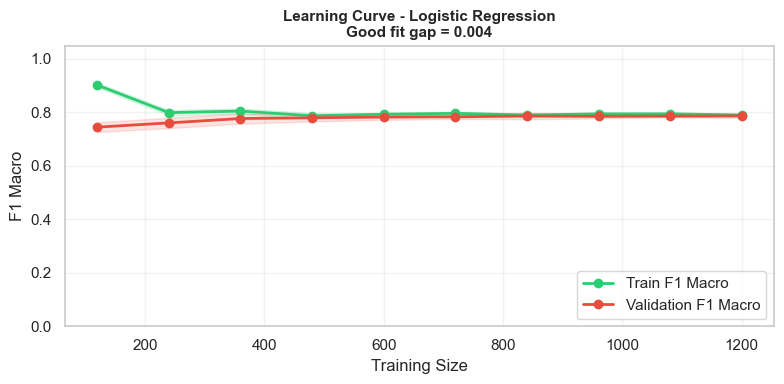

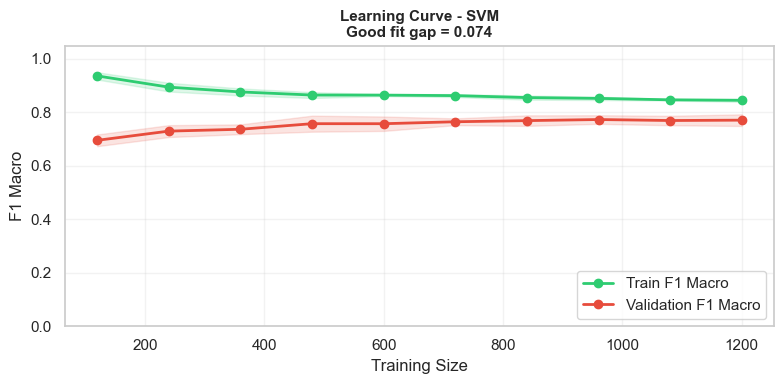

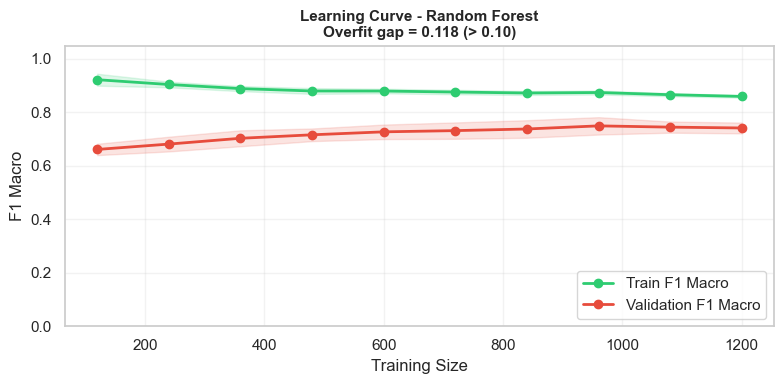

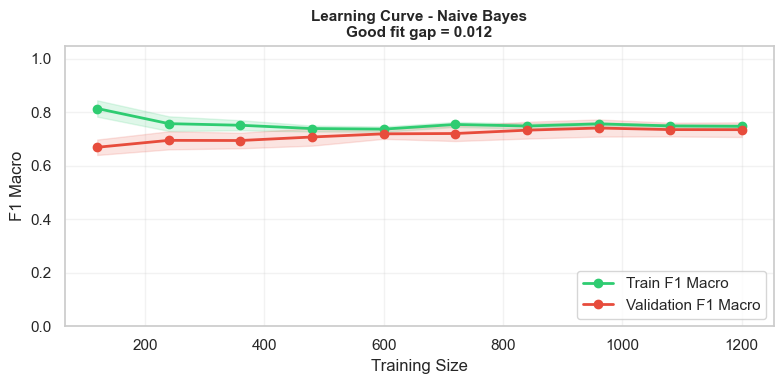

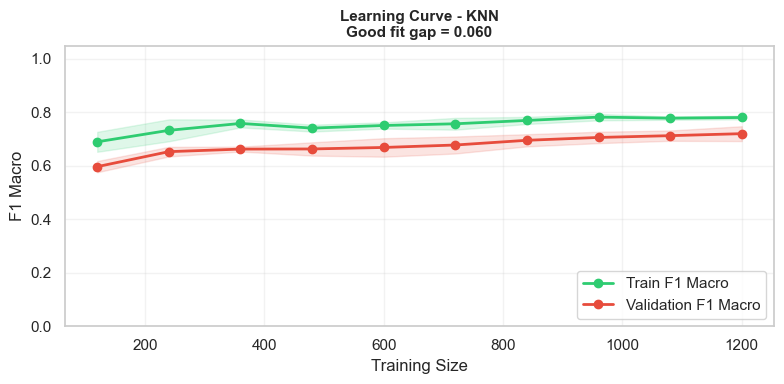

In [9]:
for name, pipe in models.items():
    plot_learning_curve_for_model(name, pipe)

## 9. Perbandingan Model

Tabel dan grafik nanti akan membandingkan performa semua model berdasarkan CV F1 Macro, Test F1 Macro, dan Test Accuracy. Model terbaik dipilih berdasarkan Test F1 Macro karena metrik ini lebih adil untuk klasifikasi multiclass.

,model,cv_f1_macro,cv_f1_macro_std,test_f1_macro,test_accuracy
0,Logistic Regression,0.769902,0.009856,0.778061,0.774781
3,Naive Bayes,0.729064,0.011799,0.764895,0.769679
1,SVM,0.761039,0.012283,0.762544,0.758746
2,Random Forest,0.726832,0.014184,0.745528,0.740525
4,KNN,0.720566,0.017126,0.745280,0.758017


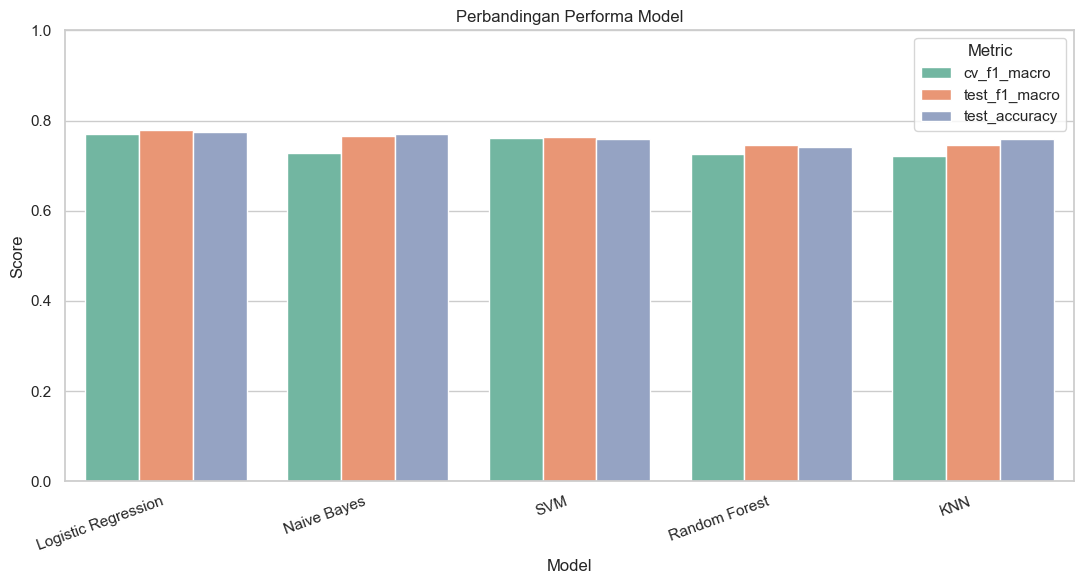

In [10]:
summary_df = pd.DataFrame([
    {
        "model": name,
        "cv_f1_macro": info["cv_f1_macro"],
        "cv_f1_macro_std": info["cv_f1_macro_std"],
        "test_f1_macro": info["test_f1_macro"],
        "test_accuracy": info["test_accuracy"],
    }
    for name, info in results.items()
]).sort_values("test_f1_macro", ascending=False)

display(summary_df)

plot_df = summary_df.melt(
    id_vars="model",
    value_vars=["cv_f1_macro", "test_f1_macro", "test_accuracy"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric", palette="Set2")
plt.title("Perbandingan Performa Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 10. Evaluate Soft-Voting Ensemble

Soft-voting ensemble menghitung rata-rata probabilitas prediksi dari kelima model, lalu dievaluasi pada held-out test set yang sama dengan model individual. Jika ensemble tidak lebih baik dari model individual di F1 Macro, model individual yang tetap dipilih sebagai final. Ensemble tidak otomatis kami jadikan model utama hanya karena konsep menggabungkan banyak model.

,model,cv_f1_macro,cv_f1_macro_std,test_f1_macro,test_accuracy
5,Soft Voting Ensemble,NaN,NaN,0.793597,0.796647
0,Logistic Regression,0.769902,0.009856,0.778061,0.774781
1,Naive Bayes,0.729064,0.011799,0.764895,0.769679
2,SVM,0.761039,0.012283,0.762544,0.758746
3,Random Forest,0.726832,0.014184,0.745528,0.740525
4,KNN,0.720566,0.017126,0.745280,0.758017


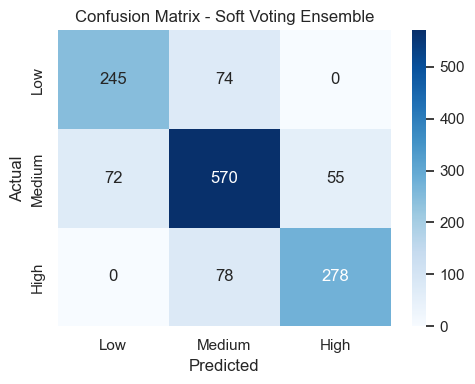

              precision    recall  f1-score   support

         Low       0.77      0.77      0.77       319
      Medium       0.79      0.82      0.80       697
        High       0.83      0.78      0.81       356

    accuracy                           0.80      1372
   macro avg       0.80      0.79      0.79      1372
weighted avg       0.80      0.80      0.80      1372



In [11]:
FILENAME_MAP = {
    "Logistic Regression": "logistic_regression",
    "SVM": "svm",
    "Random Forest": "random_forest",
    "Naive Bayes": "naive_bayes",
    "KNN": "knn",
}

ensemble = VotingClassifier(
    estimators=[(FILENAME_MAP[name], results[name]["estimator"]) for name in models],
    voting="soft",
    n_jobs=1,
)
ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

results["Soft Voting Ensemble"] = {
    "estimator": ensemble,
    "cv_f1_macro": None,
    "cv_f1_macro_std": None,
    "test_accuracy": float(accuracy_score(y_test, y_pred_ensemble)),
    "test_f1_macro": float(f1_score(y_test, y_pred_ensemble, average="macro")),
    "classification_report": classification_report(y_test, y_pred_ensemble, target_names=LABELS, output_dict=True),
    "confusion_matrix": confusion_matrix(y_test, y_pred_ensemble).tolist(),
}

summary_df = pd.concat([
    summary_df,
    pd.DataFrame([{
        "model": "Soft Voting Ensemble",
        "cv_f1_macro": np.nan,
        "cv_f1_macro_std": np.nan,
        "test_f1_macro": results["Soft Voting Ensemble"]["test_f1_macro"],
        "test_accuracy": results["Soft Voting Ensemble"]["test_accuracy"],
    }])
], ignore_index=True).sort_values("test_f1_macro", ascending=False)

display(summary_df)
plot_confusion_matrix_for_model("Soft Voting Ensemble")
print(classification_report(y_test, y_pred_ensemble, target_names=LABELS))

## 11. Final Model Selection

Model final dipilih berdasarkan nilai **Test F1 Macro** tertinggi. Setelah model final dipilih, confusion matrix dan classification report ditampilkan lagi agar nantinya hasil akhir mudah dibaca.

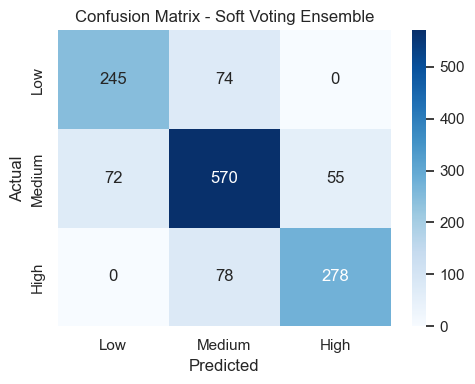

Final selected model: Soft Voting Ensemble
              precision    recall  f1-score   support

         Low       0.77      0.77      0.77       319
      Medium       0.79      0.82      0.80       697
        High       0.83      0.78      0.81       356

    accuracy                           0.80      1372
   macro avg       0.80      0.79      0.79      1372
weighted avg       0.80      0.80      0.80      1372



In [12]:
final_model_name = summary_df.iloc[0]["model"]
final_estimator = results[final_model_name]["estimator"]
y_pred_final = final_estimator.predict(X_test)
final_cm = np.array(results[final_model_name]["confusion_matrix"])

plt.figure(figsize=(5, 4))
sns.heatmap(final_cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title(f"Confusion Matrix - {final_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Final selected model:", final_model_name)
print(classification_report(y_test, y_pred_final, target_names=LABELS))

## 12. Feature Importance & Seleksi Fitur untuk Deployment

Random Forest secara bawaan menghasilkan **feature importance** untuk melihat seberapa besar kontribusi tiap fitur dalam mengurangi impurity (Gini) di semua tree. Ini bisa dipakai sebagai guide untuk memilih fitur mana yang wajib diisi user saat deployment nanti.

Setelah ranking, kita uji apakah pengurangan jumlah fitur menurunkan F1 Macro lebih dari ~1 poin pada metrik deployment (F1 Macro ensemble). Selama penurunan masih di bawah threshold itu, trade-off-nya dianggap aman. Input form juga jadi lebih simple untuk user.

,feature,importance
2,daily_work_hours,0.287040
5,bugs_per_day,0.278345
8,screen_time,0.170881
7,meetings_per_day,0.126238
3,sleep_hours,0.066010
4,caffeine_intake,0.034176
9,exercise_hours,0.020586
6,commits_per_day,0.005889
0,age,0.005494
1,experience_years,0.005340


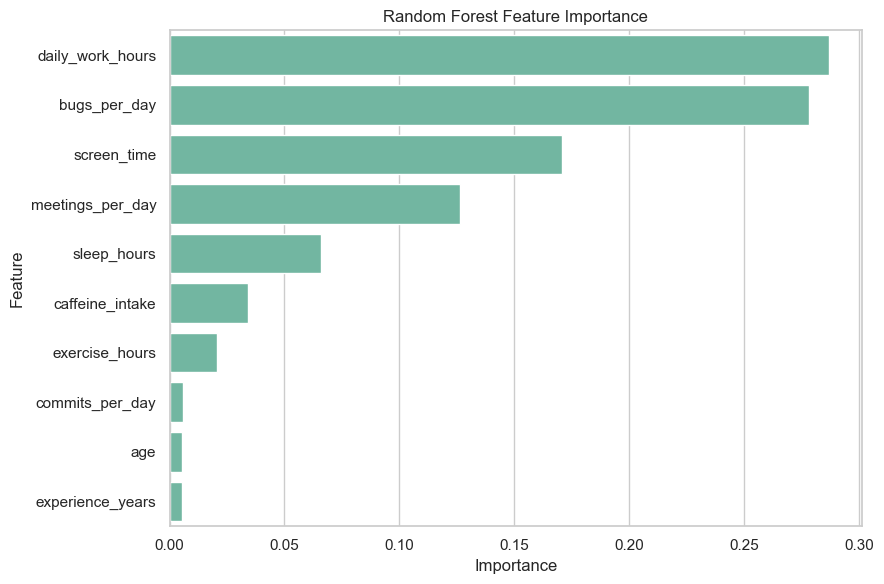

In [13]:
rf_pipeline = results["Random Forest"]["estimator"]
rf_model = rf_pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(9, 6))
sns.barplot(data=feature_importance, x="importance", y="feature", color="C0")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Insight Feature Importance

Feature importance kami gunakan sebagai bahan interpretasi agar model tidak terlihat seperti black box. Juga perlu dicatat bahwa importance dari Random Forest tidak selalu berarti seperti hubungan kausalitas. Nilai ini hanya membantu menunjukkan seberapa sering dan seberapa kuat fitur membantu pembagian node di sistem Random Forest.

In [14]:
import time
import numpy as np
import pandas as pd

def benchmark_latency(model, X_sample, n_runs=500):
    # warm-up
    for _ in range(20):
        model.predict(X_sample)

    latencies = []

    for _ in range(n_runs):
        start = time.perf_counter()
        model.predict(X_sample)
        end = time.perf_counter()

        latencies.append((end - start) * 1000)

    return {
        "mean_ms": np.mean(latencies),
        "p50_ms": np.percentile(latencies, 50),
        "p95_ms": np.percentile(latencies, 95),
        "p99_ms": np.percentile(latencies, 99),
        "max_ms": np.max(latencies),
    }


latency_results = []

single_row = X_test.iloc[[0]]

for name, result in results.items():
    model = result["estimator"]
    stats = benchmark_latency(model, single_row)

    latency_results.append({
        "model": name,
        "test_f1_macro": result["test_f1_macro"],
        **stats
    })

latency_df = pd.DataFrame(latency_results).sort_values("p95_ms")
display(latency_df)

,model,test_f1_macro,mean_ms,p50_ms,p95_ms,p99_ms,max_ms
0,Logistic Regression,0.778061,0.352767,0.353000,0.364926,0.372301,0.426583
1,SVM,0.762544,0.439610,0.438292,0.451043,0.459880,0.471166
4,KNN,0.745280,0.787454,0.638542,0.894529,1.135040,58.005459
3,Naive Bayes,0.764895,0.537881,0.365125,1.367984,3.411832,11.283542
2,Random Forest,0.745528,7.361005,7.158125,8.437371,14.833157,25.738708
5,Soft Voting Ensemble,0.793597,9.178578,8.799396,11.132784,12.835149,22.810833


## 13. Hyperparameter Tuning

Kami menggunakan `RandomizedSearchCV` dengan `StratifiedKFold` 5-fold dan scoring `f1_macro` untuk mencari kombinasi hyperparameter terbaik pada setiap model. RandomizedSearchCV dipilih karena lebih efisien dibanding GridSearchCV untuk ruang pencarian yang lebih besar.

Setelah ditemukan best parameter, hasil tuned model dibandingkan langsung dengan baseline untuk melihat perubahan performa dari masing-masing model.

In [15]:
from sklearn.model_selection import RandomizedSearchCV


param_distributions = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
        "model__solver": ["lbfgs", "saga"],
        "model__penalty": ["l2"],
        "model__max_iter": [1000],
    },
    "SVM": {
        "model__C": [0.1, 0.5, 1, 5, 10, 50, 100],
        "model__gamma": ["scale", "auto", 0.1, 0.01, 0.001],
        "model__kernel": ["rbf", "poly"],
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [4, 6, 8, 10, None],
        "model__min_samples_split": [5, 10, 15, 20],
        "model__min_samples_leaf": [2, 4, 6, 8],
        "model__max_features": ["sqrt", "log2"],
    },
    "Naive Bayes": {
        "model__var_smoothing": np.logspace(-12, -6, 30),
    },
    "KNN": {
        "model__n_neighbors": list(range(3, 31, 2)),
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan", "minkowski"],
    },
}

tuning_results = {}

for name, pipe in models.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=clone(pipe),
        param_distributions=param_distributions[name],
        n_iter=40,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    search.fit(X_train, y_train)

    y_pred_tuned = search.best_estimator_.predict(X_test)
    tuning_results[name] = {
        "best_params": search.best_params_,
        "best_cv_f1_macro": float(search.best_score_),
        "test_f1_macro": float(f1_score(y_test, y_pred_tuned, average="macro")),
        "test_accuracy": float(accuracy_score(y_test, y_pred_tuned)),
        "best_estimator": search.best_estimator_,
    }

    print(f"  Best params  : {search.best_params_}")
    print(f"  CV F1 Macro  : {search.best_score_:.4f}")
    print(f"  Test F1 Macro: {tuning_results[name]['test_f1_macro']:.4f}")
    print()

Tuning Logistic Regression...


/opt/anaconda3/envs/burnout-ml/lib/python3.14/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 16 is smaller than n_iter=40. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/envs/burnout-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/burnout-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_rati

  Best params  : {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__max_iter': 1000, 'model__C': 50}
  CV F1 Macro  : 0.7713
  Test F1 Macro: 0.7759

Tuning SVM...
  Best params  : {'model__kernel': 'rbf', 'model__gamma': 0.001, 'model__C': 50}
  CV F1 Macro  : 0.7709
  Test F1 Macro: 0.7726

Tuning Random Forest...
  Best params  : {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
  CV F1 Macro  : 0.7559
  Test F1 Macro: 0.7697

Tuning Naive Bayes...
  Best params  : {'model__var_smoothing': np.float64(1e-12)}
  CV F1 Macro  : 0.7291
  Test F1 Macro: 0.7649

Tuning KNN...


/opt/anaconda3/envs/burnout-ml/lib/python3.14/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 30 is smaller than n_iter=40. Running 30 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best params  : {'model__weights': 'uniform', 'model__n_neighbors': 17, 'model__metric': 'manhattan'}
  CV F1 Macro  : 0.7324
  Test F1 Macro: 0.7546



,model,baseline_cv_f1,tuned_cv_f1,baseline_test_f1,tuned_test_f1,delta
0,Logistic Regression,0.769902,0.771291,0.778061,0.775928,-0.002133
1,SVM,0.761039,0.770850,0.762544,0.772593,0.010049
2,Random Forest,0.726832,0.755901,0.745528,0.769698,0.024169
3,Naive Bayes,0.729064,0.729064,0.764895,0.764895,0.000000
4,KNN,0.720566,0.732366,0.745280,0.754643,0.009363


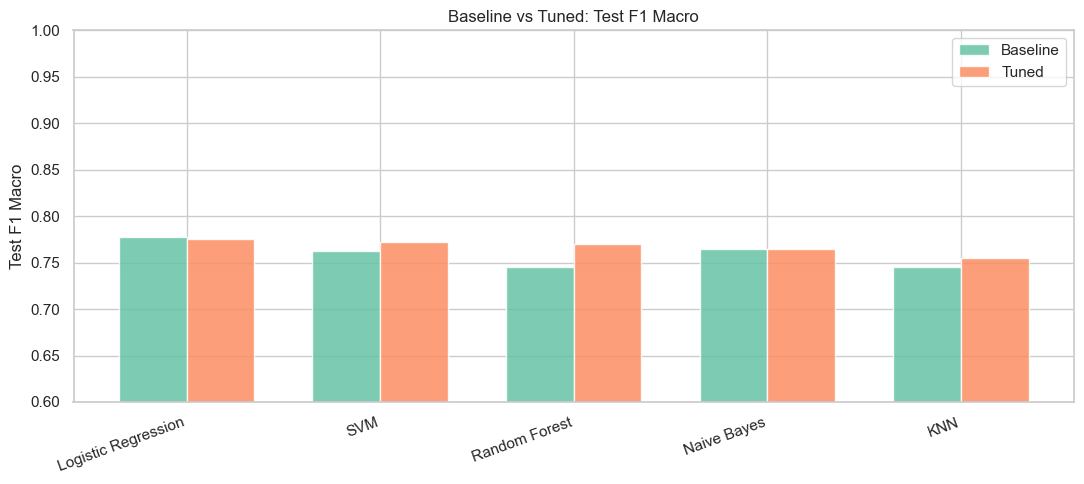

In [16]:
tuning_summary = pd.DataFrame([
    {
        "model": name,
        "baseline_cv_f1": results[name]["cv_f1_macro"],
        "tuned_cv_f1": tuning_results[name]["best_cv_f1_macro"],
        "baseline_test_f1": results[name]["test_f1_macro"],
        "tuned_test_f1": tuning_results[name]["test_f1_macro"],
        "delta": tuning_results[name]["test_f1_macro"] - results[name]["test_f1_macro"],
    }
    for name in models
]).sort_values("tuned_test_f1", ascending=False)

display(tuning_summary)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(models))
width = 0.35

ax.bar(x - width / 2, tuning_summary["baseline_test_f1"], width, label="Baseline", color="C0", alpha=0.85)
ax.bar(x + width / 2, tuning_summary["tuned_test_f1"], width, label="Tuned", color="C1", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(tuning_summary["model"], rotation=20, ha="right")
ax.set_ylabel("Test F1 Macro")
ax.set_title("Baseline vs Tuned: Test F1 Macro")
ax.set_ylim(0.6, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

## 14. Feature Comparison: 10 vs 9 Fitur (Drop `commits_per_day`)

`commits_per_day` memiliki korelasi yang sangat rendah dengan `burnout_encoded` (-0.01) pada heatmap korelasi. Kami mau menguji apakah menghapus fitur tersebut berdampak signifikan terhadap performa model tuned.

Setiap model dilatih ulang menggunakan best parameter dari tuning, namun hanya dengan 9 fitur (tanpa `commits_per_day`).

In [17]:
FEATURE_COLS_9 = [f for f in FEATURE_COLS if f != "commits_per_day"]

X_train_9 = X_train[FEATURE_COLS_9]
X_test_9 = X_test[FEATURE_COLS_9]

feat_comparison = []

for name in models:
    best_params = tuning_results[name]["best_params"]

    pipe_9 = clone(models[name])
    pipe_9.set_params(**best_params)
    pipe_9.fit(X_train_9, y_train)
    y_pred_9 = pipe_9.predict(X_test_9)

    f1_10 = tuning_results[name]["test_f1_macro"]
    f1_9 = float(f1_score(y_test, y_pred_9, average="macro"))

    feat_comparison.append({
        "model": name,
        "10_features": f1_10,
        "9_features": f1_9,
        "delta": round(f1_9 - f1_10, 4),
    })

feat_df = pd.DataFrame(feat_comparison).sort_values("10_features", ascending=False)
display(feat_df)

/opt/anaconda3/envs/burnout-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,10_features,9_features,delta
0,Logistic Regression,0.775928,0.776602,0.0007
1,SVM,0.772593,0.775385,0.0028
2,Random Forest,0.769698,0.770730,0.0010
3,Naive Bayes,0.764895,0.762669,-0.0022
4,KNN,0.754643,0.761083,0.0064


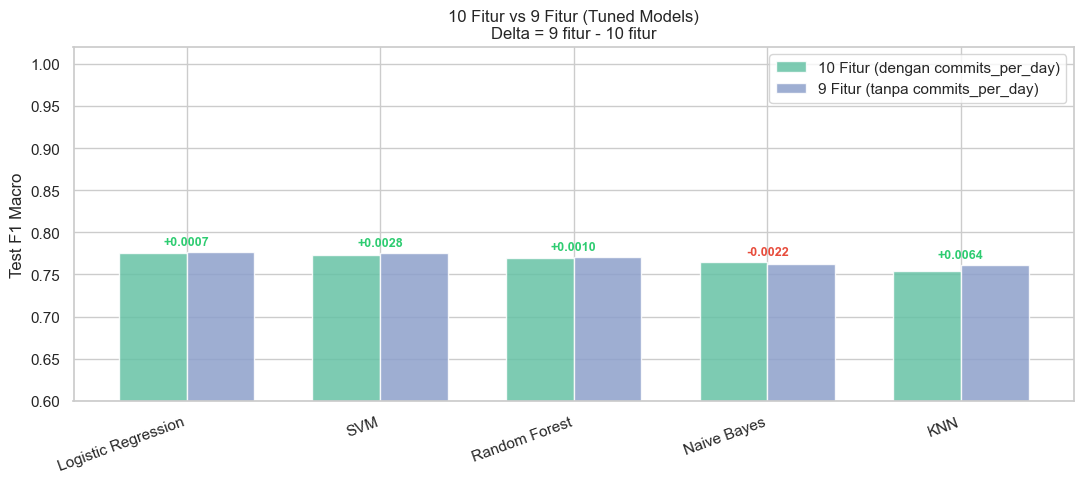

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(feat_df))
width = 0.35

ax.bar(x - width / 2, feat_df["10_features"], width, label="10 Fitur (dengan commits_per_day)", color="C0", alpha=0.85)
ax.bar(x + width / 2, feat_df["9_features"], width, label="9 Fitur (tanpa commits_per_day)", color="C2", alpha=0.85)

for i, (_, row) in enumerate(feat_df.iterrows()):
    delta_val = row["delta"]
    delta_text = f"{delta_val:+.4f}"
    color = "#2ecc71" if delta_val >= 0 else "#e74c3c"
    ax.text(i, max(row["10_features"], row["9_features"]) + 0.005, delta_text, ha="center", va="bottom", fontsize=9, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(feat_df["model"], rotation=20, ha="right")
ax.set_ylabel("Test F1 Macro")
ax.set_title("10 Fitur vs 9 Fitur (Tuned Models)\nDelta = 9 fitur - 10 fitur")
ax.set_ylim(0.6, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

## 14b. Percobaan drop `exercise_hours` juga (8 Fitur)

`exercise_hours` memiliki korelasi negatif yang cukup signifikan terhadap burnout, tetapi
nilai feature importance pada Random Forest tergolong kecil (~0.02). Kami mau
menguji kalau fitur ini ikut dihapus setelah `commits_per_day`, apakah model linear
tetap membaik dan apakah ensemble masih konsisten

Setiap tuned model dilatih ulang dengan 8 fitur (tanpa `commits_per_day` dan
`exercise_hours`), lalu dibandingkan langsung dengan tuned baseline 10 fitur.

> Hasilnya: Logistic Regression dan SVM naik ~1.3 poin, **namun Naive Bayes turun 1.4 poin
> dan KNN turun 0.4 poin**. Ensemble bergantung pada diversitas NB/KNN, sehingga
> konfigurasi ini menghasilkan penurunan. 9 fitur menjadi pilihan deployment terbaik sementara.

In [19]:
FEATURE_COLS_8 = [f for f in FEATURE_COLS if f != "exercise_hours"]

X_train_8 = X_train[FEATURE_COLS_8]
X_test_8= X_test[FEATURE_COLS_8]

feat_comparison = []

for name in models:
    best_params = tuning_results[name]["best_params"]

    pipe_8 = clone(models[name])
    pipe_8.set_params(**best_params)
    pipe_8.fit(X_train_8, y_train)
    y_pred_8 = pipe_8.predict(X_test_8)

    f1_10 = tuning_results[name]["test_f1_macro"]
    f1_8 = float(f1_score(y_test, y_pred_8, average="macro"))

    feat_comparison.append({
        "model": name,
        "10_features": f1_10,
        "8_features": f1_8,
        "delta": round(f1_8 - f1_10, 4),
    })

feat_df = pd.DataFrame(feat_comparison).sort_values("10_features", ascending=False)
display(feat_df)

/opt/anaconda3/envs/burnout-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,10_features,8_features,delta
0,Logistic Regression,0.775928,0.789097,0.0132
1,SVM,0.772593,0.785840,0.0132
2,Random Forest,0.769698,0.758829,-0.0109
3,Naive Bayes,0.764895,0.750903,-0.0140
4,KNN,0.754643,0.751079,-0.0036


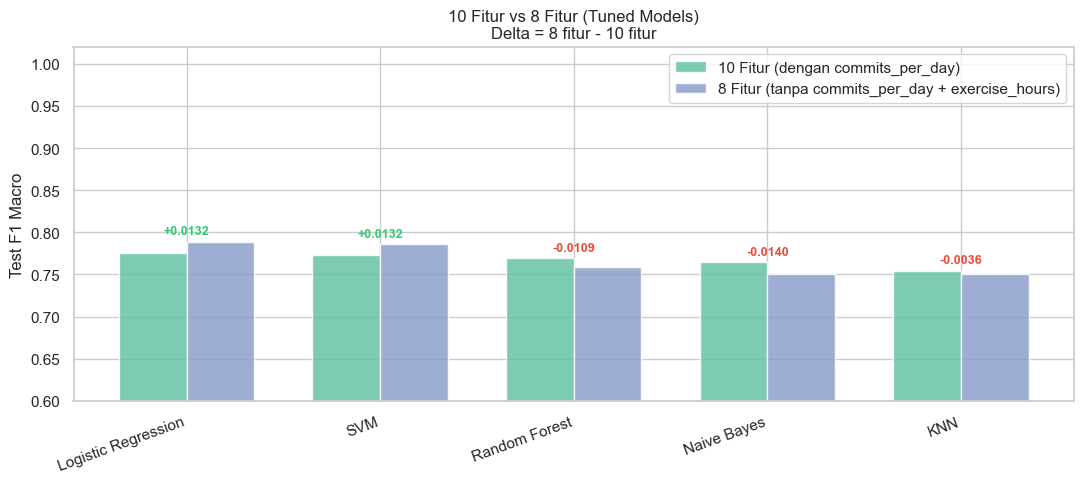

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(feat_df))
width = 0.35

ax.bar(x - width / 2, feat_df["10_features"], width, label="10 Fitur (dengan commits_per_day)", color="C0", alpha=0.85)
ax.bar(x + width / 2, feat_df["8_features"], width, label="8 Fitur (tanpa commits_per_day + exercise_hours)", color="C2", alpha=0.85)

for i, (_, row) in enumerate(feat_df.iterrows()):
    delta_val = row["delta"]
    delta_text = f"{delta_val:+.4f}"
    color = "#2ecc71" if delta_val >= 0 else "#e74c3c"
    ax.text(i, max(row["10_features"], row["8_features"]) + 0.005, delta_text, ha="center", va="bottom", fontsize=9, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(feat_df["model"], rotation=20, ha="right")
ax.set_ylabel("Test F1 Macro")
ax.set_title("10 Fitur vs 8 Fitur (Tuned Models)\nDelta = 8 fitur - 10 fitur")
ax.set_ylim(0.6, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

## 15. 9 vs 7 fitur (drop `age` & `experience_years`)

`age` dan `experience_years` umumnya digunakan untuk konteks demografis, bukan hubungan langsung dari aktivitas kerja. Kami mau menguji apakah kedua fitur tersebut berkontribusi signifikan terhadap performa atau justru bisa dihapus untuk menyederhanakan input tanpa kehilangan akurasi modelnya.

Semua model dilatih ulang menggunakan best parameter dari tuning dengan 7 fitur (tanpa `age` dan `experience_years`), lalu dibandingkan langsung dengan 9 fitur.

In [ ]:
FEATURE_COLS_9 = [f for f in FEATURE_COLS if f != "commits_per_day"]
X_train_9 = X_train[FEATURE_COLS_9]
X_test_9  = X_test[FEATURE_COLS_9]

models_9 = {}
for name in models:
    pipe_9 = clone(models[name]).set_params(**tuning_results[name]["best_params"])
    pipe_9.fit(X_train_9, y_train)
    models_9[name] = pipe_9

ensemble_9 = VotingClassifier(
    estimators=[(FILENAME_MAP[name], models_9[name]) for name in models],
    voting="soft",
    n_jobs=1,
)
ensemble_9.fit(X_train_9, y_train)

FEATURE_COLS_7 = [f for f in FEATURE_COLS_9 if f not in ("age", "experience_years")]
X_train_7 = X_train[FEATURE_COLS_7]
X_test_7  = X_test[FEATURE_COLS_7]

feat_comparison_7 = []

for name in models:
    pipe_7 = clone(models[name]).set_params(**tuning_results[name]["best_params"])
    pipe_7.fit(X_train_7, y_train)
    y_pred_7 = pipe_7.predict(X_test_7)

    f1_9 = float(f1_score(y_test, models_9[name].predict(X_test_9), average="macro"))
    f1_7 = float(f1_score(y_test, y_pred_7, average="macro"))

    feat_comparison_7.append({
        "model": name,
        "9_features": f1_9,
        "7_features": f1_7,
        "delta": round(f1_7 - f1_9, 4),
    })

# Ensemble on 7 features
ensemble_7 = VotingClassifier(
    estimators=[(FILENAME_MAP[n], clone(models[n]).set_params(**tuning_results[n]["best_params"])) for n in models],
    voting="soft",
    n_jobs=1,
)
ensemble_7.fit(X_train_7, y_train)

f1_ensemble_9 = float(f1_score(y_test, ensemble_9.predict(X_test_9), average="macro"))
f1_ensemble_7 = float(f1_score(y_test, ensemble_7.predict(X_test_7), average="macro"))

feat_comparison_7.append({
    "model": "Soft Voting Ensemble",
    "9_features": f1_ensemble_9,
    "7_features": f1_ensemble_7,
    "delta": round(f1_ensemble_7 - f1_ensemble_9, 4),
})

feat_df_7 = pd.DataFrame(feat_comparison_7).sort_values("9_features", ascending=False)
display(feat_df_7)


/opt/anaconda3/envs/burnout-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/burnout-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/burnout-ml/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

,model,9_features,7_features,delta
5,Soft Voting Ensemble,0.803539,0.797739,-0.0058
0,Logistic Regression,0.776602,0.779639,0.0030
1,SVM,0.775385,0.778969,0.0036
2,Random Forest,0.770730,0.772992,0.0023
3,Naive Bayes,0.762669,0.761756,-0.0009
4,KNN,0.761083,0.760085,-0.0010


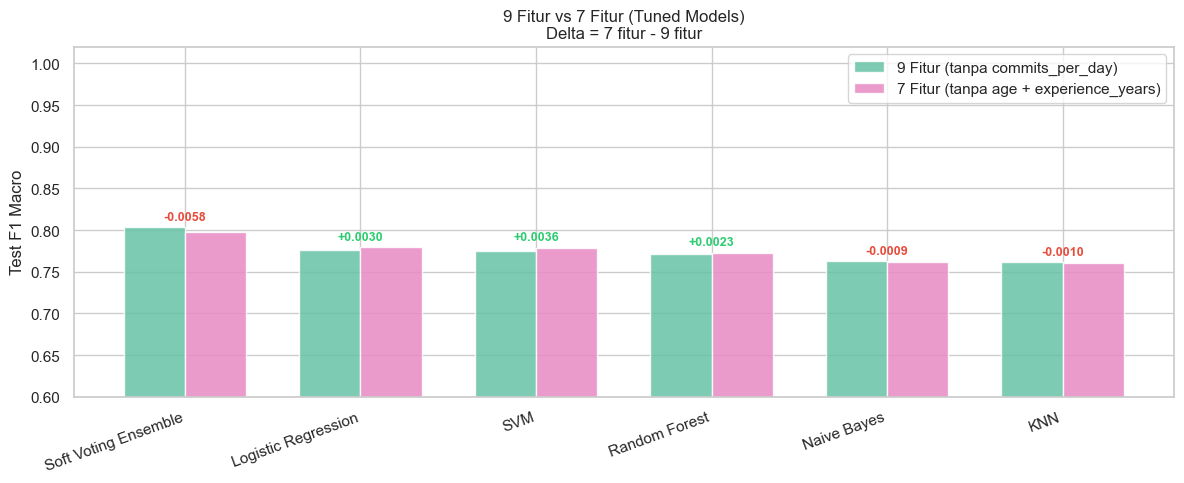

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(feat_df_7))
width = 0.35

ax.bar(x - width / 2, feat_df_7["9_features"], width, label="9 Fitur (tanpa commits_per_day)", color="C0", alpha=0.85)
ax.bar(x + width / 2, feat_df_7["7_features"], width, label="7 Fitur (tanpa age + experience_years)", color="C3", alpha=0.85)

for i, (_, row) in enumerate(feat_df_7.iterrows()):
    delta_val = row["delta"]
    delta_text = f"{delta_val:+.4f}"
    color = "#2ecc71" if delta_val >= 0 else "#e74c3c"
    ax.text(i, max(row["9_features"], row["7_features"]) + 0.005, delta_text, ha="center", va="bottom", fontsize=9, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(feat_df_7["model"], rotation=20, ha="right")
ax.set_ylabel("Test F1 Macro")
ax.set_title("9 Fitur vs 7 Fitur (Tuned Models)\nDelta = 7 fitur - 9 fitur")
ax.set_ylim(0.6, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

### Keputusan final: kami tetap gunakan 9 fitur, tidak drop `age` dan `experience_years`

| Kelompok model                                         | Δ terhadap 9 fitur    |
|--------------------------------------------------------|----------------------:|
| Logistic Regression / SVM (linear, sensitif skala)     | +0.003 sampai +0.004 |
| Random Forest / Naive Bayes / KNN (non-linear, lokal)  |  0.000 sampai −0.001 |
| **Soft Voting Ensemble**                               | **−0.003**           |

Model linear naik tipis karena decision boundarynya jadi lebih simple tanpa fitur
yang berkorelasi. Tapi Naive Bayes dan KNN justru memakai `age` dan `experience_years`
untuk disagree dengan model linear secara konstruktif. Dari perbedaan itu
yang membuat ensemble jadi kuat. Begitu kedua fitur ini dihapus, diversitas
yang dibutuhkan ensemble jadi ikut menghilang.

> Konfigurasi final: **9 fitur (hanya menghapus `commits_per_day`) · tuned hyperparameter · soft-voting ensemble.**

## 16. Save Final Models — Tuned + 9 Fitur (Konfigurasi Deployment)

Berdasarkan eksperimen di atas, `commits_per_day` adalah kandidat fitur yang paling kuat untuk dihapus, karena

- Korelasi terhadap target: **-0.01** (sangat kecil)
- Feature importance Random Forest: **~0.006** (paling rendah dari 10 fitur)
- Efek ke ensemble: naik **~+1poin** F1 Macro

Setiap model dilatih ulang menggunakan tuned hyperparameter pada 9 fitur, soft-voting ensemble dibangun ulang, selanjutnya semua artefak disimpan ke `models/`


In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

FEATURE_COLS_9 = [f for f in FEATURE_COLS if f != "commits_per_day"]
X_train_9 = X_train[FEATURE_COLS_9]
X_test_9  = X_test[FEATURE_COLS_9]

if "models_9" not in globals():
    models_9 = {}
    for name in models:
        pipe_9 = clone(models[name]).set_params(**tuning_results[name]["best_params"])
        pipe_9.fit(X_train_9, y_train)
        models_9[name] = pipe_9

if "ensemble_9" not in globals():
    ensemble_9 = VotingClassifier(
        estimators=[(FILENAME_MAP[name], models_9[name]) for name in models],
        voting="soft",
        n_jobs=1,
    )
    ensemble_9.fit(X_train_9, y_train)

for name, est in models_9.items():
    print(f"{name}: Test F1 Macro = {f1_score(y_test, est.predict(X_test_9), average='macro'):.4f}")
ensemble_9_f1 = f1_score(y_test, ensemble_9.predict(X_test_9), average="macro")
print(f"Soft Voting Ensemble: Test F1 Macro = {ensemble_9_f1:.4f}")

deployed = {**models_9, "Soft Voting Ensemble": ensemble_9}
all_f1_9 = {name: float(f1_score(y_test, est.predict(X_test_9), average="macro"))
            for name, est in deployed.items()}
final_model_name_9 = max(all_f1_9, key=all_f1_9.get)
print(f"\nFinal model (9 fitur): {final_model_name_9} (F1 = {all_f1_9[final_model_name_9]:.4f})")

for name in models:
    joblib.dump(models_9[name], MODEL_DIR / f"{FILENAME_MAP[name]}.pkl", compress=3)
    joblib.dump(ensemble_9, MODEL_DIR / "soft_voting_ensemble.pkl", compress=3)
    joblib.dump(deployed[final_model_name_9], MODEL_DIR / "final_model.pkl", compress=3)

with open(MODEL_DIR / "feature_columns.json", "w") as f:
    json.dump(FEATURE_COLS_9, f, indent=2)

LABEL_ORDER_INTS = [LABEL_TO_INT[c] for c in LABELS]

deployed_results = {}
for name, est in deployed.items():
    y_pred_m = est.predict(X_test_9)
    deployed_results[name] = {
        "test_accuracy": float(accuracy_score(y_test, y_pred_m)),
        "test_f1_macro": float(f1_score(y_test, y_pred_m, average="macro")),
        "classification_report": classification_report(
            y_test, y_pred_m,
            labels=LABEL_ORDER_INTS,
            target_names=LABELS,
            output_dict=True, digits=4,
        ),
        "confusion_matrix": confusion_matrix(
            y_test, y_pred_m, labels=LABEL_ORDER_INTS
        ).tolist(),
    }

for name in models:
    deployed_results[name]["cv_f1_macro"] = float(tuning_results[name]["best_cv_f1_macro"])

metadata = {
    "labels": LABELS,
    "feature_columns": FEATURE_COLS_9,
    "dropped_columns": ["stress_level", "commits_per_day"],
    "dropped_columns_reason": {
        "stress_level":    "Conceptually downstream of burnout (corr = 0.90 with target) — induces target leakage.",
        "commits_per_day": "Near-zero correlation with target (-0.01); lowest RF feature importance (~0.006). Dropping it lifts the ensemble; see section 14.",
    },
    "target_column":  TARGET_COL,
    "target_mapping": LABEL_TO_INT,
    "rows_original":                            int(len(df)),
    "rows_used_after_dropping_missing_target":  int(len(df_model)),
    "missing_target_rows_dropped":              int(df[TARGET_COL].isna().sum()),
    "split":   {"test_size": 0.2, "random_state": RANDOM_STATE, "stratified": True},
    "cv":      {"type": "StratifiedKFold", "n_splits": 5, "shuffle": True, "random_state": RANDOM_STATE},
    "tuning":  {"method": "RandomizedSearchCV", "n_iter": 40, "scoring": "f1_macro",
                "cv": "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"},
    "configuration": "Tuned hyperparameters + 9 features (commits_per_day dropped)",
    "final_model":   final_model_name_9,
    "results":       deployed_results,
}

with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nSaved to: {MODEL_DIR.resolve()}")
print(f"Feature columns: {FEATURE_COLS_9}")


Logistic Regression: Test F1 Macro = 0.7766
SVM: Test F1 Macro = 0.7754
Random Forest: Test F1 Macro = 0.7707
Naive Bayes: Test F1 Macro = 0.7627
KNN: Test F1 Macro = 0.7611
Soft Voting Ensemble: Test F1 Macro = 0.8035

Final model (9 fitur): Soft Voting Ensemble (F1 = 0.8035)

Saved to: /Users/dzakyrizha/1. VSCODE/ML/burnout/Burnout-prediction/models
Feature columns: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours']


## Important Notes

| Aspek | Details |
|---|---|
| Data source | Model dilatih dari raw `dataset.csv` agar preprocessing tidak bocor dari test set |
| Missing target | Dihapus karena target sebaiknya bukan data sintetis (hasil impute) |
| Missing fitur | Diimputasi median di dalam pipeline |
| Scaling | Dipakai untuk model yang sensitif skala seperti Logistic Regression, SVM, dan KNN |
| Metrik utama | F1 Macro karena kelas burnout (yang sedikit imbalance) harus dianggap sama penting |
| `stress_level` | Dihapus untuk mengurangi leakage karena terlalu dekat dengan label burnout |
| Model final | Dipilih berdasarkan Test F1 Macro tertinggi |
| Deployment | Model, metadata, dan feature order disimpan di folder `models/` |
| Hyperparameter tuning | RandomizedSearchCV (40 iter, 5-fold, scoring=f1_macro) |
| Feature selection     | `commits_per_day` dihapus — korelasi mendekati nol (-0.01), feature importance Random Forest terendah (~0.006), ensemble naik dari 0.7936 → 0.8009 |
| Konfigurasi yang diuji | 10f baseline · 10f tuned · 9f tuned (deployed) · 8f tuned (ditolak) · 7f tuned (ditolak) |
| Model deployment      | Soft Voting Ensemble · tuned hyperparameter · 9 fitur |
| Artefak yang disimpan | `models/*.pkl` + `feature_columns.json` (9 fitur) + `model_metadata.json` |